<a href="https://colab.research.google.com/github/Squirrelcoding/ISLP/blob/main/Lab_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm

In [2]:
from statsmodels.stats.outliers_influence \
  import variance_inflation_factor as VIF
from statsmodels.stats.anova import anova_lm

In [3]:
%pip install ISLP

In [4]:
from ISLP import load_data
from ISLP.models import (ModelSpec as MS, summarize, poly)

In [5]:
A = np.array([3, 5, 11])
A.sum()

19

In [6]:
Boston = load_data("Boston")
Boston.columns

Index(['crim', 'zn', 'indus', 'chas', 'nox', 'rm', 'age', 'dis', 'rad', 'tax',
       'ptratio', 'lstat', 'medv'],
      dtype='object')

In [7]:
X = pd.DataFrame({
    "intercept": np.ones(Boston.shape[0]),
    "lstat": Boston['lstat']
})

X[:4]

,intercept,lstat
0,1.0,4.98
1,1.0,9.14
2,1.0,4.03
3,1.0,2.94


In [8]:
y = Boston['medv']
model = sm.OLS(y, X)
results = model.fit()

In [9]:
summarize(results)

,coef,std err,t,P>|t|
intercept,34.5538,0.563,61.415,0.0
lstat,-0.9500,0.039,-24.528,0.0


In [10]:
design = MS(['lstat'])
design = design.fit(Boston)
X = design.transform(Boston)

X[:4]

,intercept,lstat
0,1.0,4.98
1,1.0,9.14
2,1.0,4.03
3,1.0,2.94


In [11]:
results.params

,0
intercept,34.553841
lstat,-0.950049


In [12]:
new_df = pd.DataFrame({"lstat": [5, 10, 15]})
newX = design.transform(new_df)

newX

,intercept,lstat
0,1.0,5
1,1.0,10
2,1.0,15


In [13]:
new_predictions = results.get_prediction(newX)
new_predictions.predicted_mean

array([29.80359411, 25.05334734, 20.30310057])

In [14]:
new_predictions.conf_int(alpha=0.05, obs=True)

array([[17.56567478, 42.04151344],
       [12.82762635, 37.27906833],
       [ 8.0777421 , 32.52845905]])

In [15]:
def abline(ax, b, m, *args, **kwargs):
  "Add a line with slope `m` and intercept `b` to `ax`"
  xlim = ax.get_xlim()
  ylim = [m * xlim[0] + b, m * xlim[1] + b]
  ax.plot(xlim, ylim, *args, **kwargs)

/tmp/ipython-input-16-199927131.py:3: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  abline(ax, results.params[0], results.params[1], 'r--', linewidth=3)


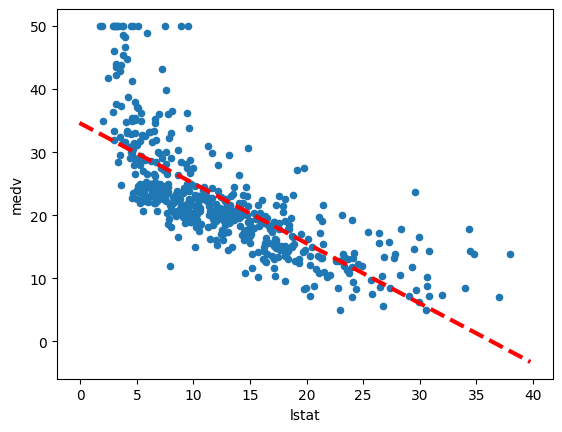

In [16]:
ax = Boston.plot.scatter("lstat", "medv")

abline(ax, results.params[0], results.params[1], 'r--', linewidth=3)

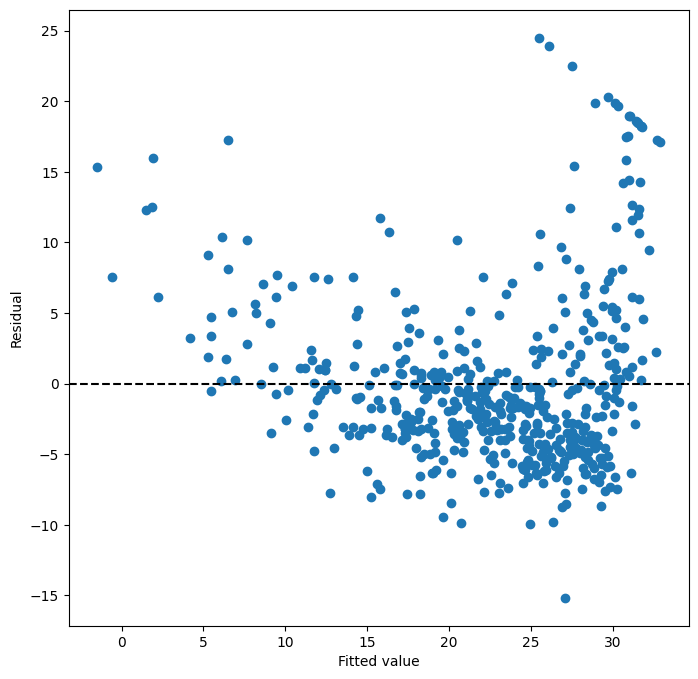

In [17]:
ax = plt.subplots(figsize=(8, 8))[1]

ax.scatter(results.fittedvalues, results.resid)
ax.set_xlabel("Fitted value")
ax.set_ylabel("Residual")
ax.axhline(0, c='k', ls='--')

374

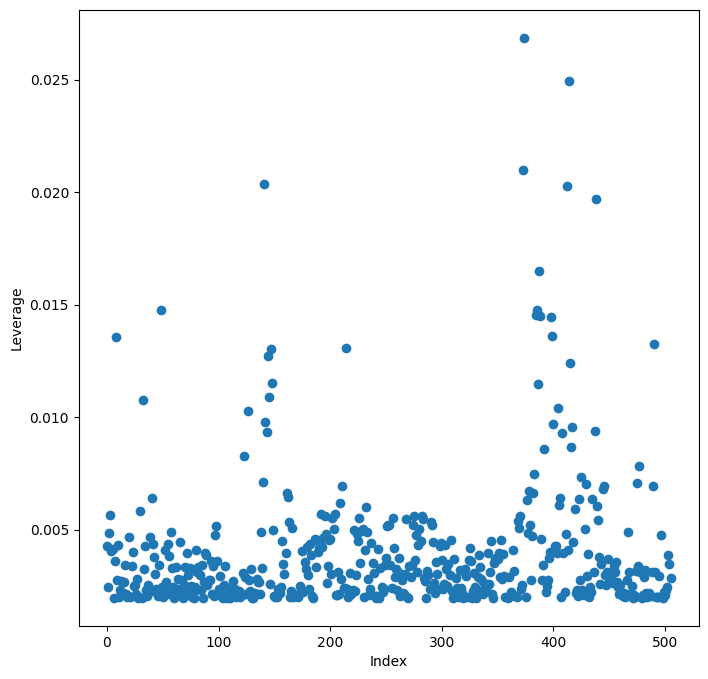

In [18]:
infl = results.get_influence()
ax = plt.subplots(figsize=(8, 8))[1]
ax.scatter(np.arange(X.shape[0]), infl.hat_matrix_diag)
ax.set_xlabel('Index')
ax.set_ylabel('Leverage')
np.argmax(infl.hat_matrix_diag)

In [19]:
X = MS(['lstat', 'age']).fit_transform(Boston)
model1 = sm.OLS(y, X)
results1 = model1.fit()
summarize(results1)

,coef,std err,t,P>|t|
intercept,33.2228,0.731,45.458,0.000
lstat,-1.0321,0.048,-21.416,0.000
age,0.0345,0.012,2.826,0.005


In [20]:
terms = Boston.columns.drop('medv')
terms

Index(['crim', 'zn', 'indus', 'chas', 'nox', 'rm', 'age', 'dis', 'rad', 'tax',
       'ptratio', 'lstat'],
      dtype='object')

In [21]:
X = MS(terms).fit_transform(Boston)
model = sm.OLS(y, X)
results = model.fit()
summarize(results)

,coef,std err,t,P>|t|
intercept,41.6173,4.936,8.431,0.000
crim,-0.1214,0.033,-3.678,0.000
zn,0.0470,0.014,3.384,0.001
indus,0.0135,0.062,0.217,0.829
chas,2.8400,0.870,3.264,0.001
nox,-18.7580,3.851,-4.870,0.000
rm,3.6581,0.420,8.705,0.000
age,0.0036,0.013,0.271,0.787
dis,-1.4908,0.202,-7.394,0.000
rad,0.2894,0.067,4.325,0.000


In [22]:
minus_age = Boston.columns.drop(['medv', 'age'])
Xma = MS(minus_age).fit_transform(Boston)
model1 = sm.OLS(y, Xma)
summarize(model1.fit())

,coef,std err,t,P>|t|
intercept,41.5251,4.920,8.441,0.000
crim,-0.1214,0.033,-3.683,0.000
zn,0.0465,0.014,3.379,0.001
indus,0.0135,0.062,0.217,0.829
chas,2.8528,0.868,3.287,0.001
nox,-18.4851,3.714,-4.978,0.000
rm,3.6811,0.411,8.951,0.000
dis,-1.5068,0.193,-7.825,0.000
rad,0.2879,0.067,4.322,0.000
tax,-0.0127,0.004,-3.333,0.001


In [23]:
np.sqrt(results.scale)

4.798034335596367

In [24]:
vals = [VIF(X, i) for i in range(1, X.shape[1])]
vif = pd.DataFrame({'vif': vals}, index=X.columns[1:])

vif

,vif
crim,1.767486
zn,2.298459
indus,3.987181
chas,1.071168
nox,4.369093
rm,1.912532
age,3.088232
dis,3.954037
rad,7.445301
tax,9.002158


In [25]:
X = MS(['lstat', 'age', ('lstat', 'age')]).fit_transform(Boston)
model2 = sm.OLS(y, X)
summarize(model2.fit())

,coef,std err,t,P>|t|
intercept,36.0885,1.470,24.553,0.000
lstat,-1.3921,0.167,-8.313,0.000
age,-0.0007,0.020,-0.036,0.971
lstat:age,0.0042,0.002,2.244,0.025


In [26]:
X = MS([poly('lstat', degree=2), 'age']).fit_transform(Boston)
model3 = sm.OLS(y, X)
results3 = model3.fit()
summarize(results3)

,coef,std err,t,P>|t|
intercept,17.7151,0.781,22.681,0.0
"poly(lstat, degree=2)[0]",-179.2279,6.733,-26.620,0.0
"poly(lstat, degree=2)[1]",72.9908,5.482,13.315,0.0
age,0.0703,0.011,6.471,0.0


In [27]:
X = MS([poly('lstat', degree=2, raw=True), 'age']).fit_transform(Boston)
model30 = sm.OLS(y, X)
results30 = model30.fit()
summarize(results30)

,coef,std err,t,P>|t|
intercept,41.2885,0.873,47.284,0.0
"poly(lstat, degree=2, raw=True)[0]",-2.6883,0.131,-20.502,0.0
"poly(lstat, degree=2, raw=True)[1]",0.0495,0.004,13.315,0.0
age,0.0703,0.011,6.471,0.0


In [28]:
anova_lm(results1, results3)

,df_resid,ssr,df_diff,ss_diff,F,Pr(>F)
0,503.0,19168.128609,0.0,NaN,NaN,NaN
1,502.0,14165.613251,1.0,5002.515357,177.278785,7.468491e-35


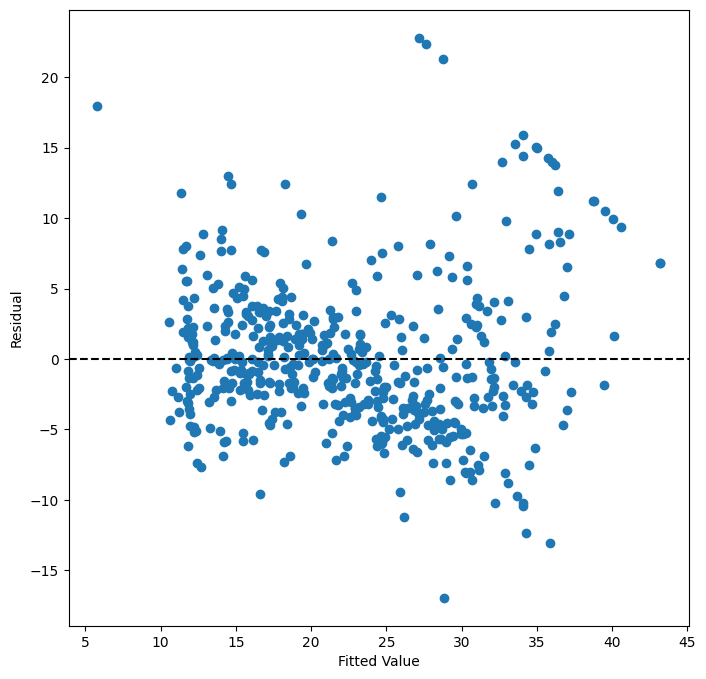

In [29]:
ax = plt.subplots(figsize=(8, 8))[1]

ax.scatter(results3.fittedvalues, results3.resid)
ax.set_xlabel('Fitted Value')
ax.set_ylabel('Residual')
ax.axhline(0, c='k', ls='--')

In [30]:
Carseats = load_data('Carseats')
Carseats.columns

Index(['Sales', 'CompPrice', 'Income', 'Advertising', 'Population', 'Price',
       'ShelveLoc', 'Age', 'Education', 'Urban', 'US'],
      dtype='object')

In [31]:
allvars = list(Carseats.columns.drop('Sales'))
y = Carseats['Sales']

final = allvars + [('Income', 'Advertising'), ('Price', 'Age')]

X = MS(final).fit_transform(Carseats)
model = sm.OLS(y, X)
summarize(model.fit())

,coef,std err,t,P>|t|
intercept,6.5756,1.009,6.519,0.000
CompPrice,0.0929,0.004,22.567,0.000
Income,0.0109,0.003,4.183,0.000
Advertising,0.0702,0.023,3.107,0.002
Population,0.0002,0.000,0.433,0.665
Price,-0.1008,0.007,-13.549,0.000
ShelveLoc[Good],4.8487,0.153,31.724,0.000
ShelveLoc[Medium],1.9533,0.126,15.531,0.000
Age,-0.0579,0.016,-3.633,0.000
Education,-0.0209,0.020,-1.063,0.288


# Conceptual Exercises

## Exercise 1

The $p$-values in Table 3.4 correspond to the null hypothesis that all of the respective coefficients are zero. If $\beta_i$ is the coefficient for the $i$th predictor, then the corresponding $p$-value is the probability that we observed the estimated coefficient based on the data, assuming that the true coefficient is zero. Therefore,

- The coefficient for `Intercept` is 2.939 and its $p$-value is less than $0.0001$. This means that if the actual coefficient is indeed zero (that is, there is no relationship), then the probability that we observed 2.939 is extremely unlikely that it's essentially impossible, so we end up rejecting the null hypothesis and conclude that it is indeed the value $2.939$. Similar reasoning can be applied to the coefficients for `TV` and `radio`.

- The $p$-value for `newspaper` is 0.8599, which is significant. It means that if the true coefficient for `newspaper` really is zero, then the probability that we observed -0.001 is very likely. This does not provide any evidence for rejecting the null hypothesis, so we "stay" with it and conclude that there is no significant relationship.

The conclusion is that `TV` and `radio` are the only two significant predictors, while `newspaper` is not significant. If we do not allocate any sales, then we will only sell around 2,939 units.

## Exercise 2


The KNN classifier is used for classification problems. Suppose that we are given an integer $K$